In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("guriya79/how-ai-is-changing-student-life")

print("Path to dataset files:", path)

Path to dataset files: /Users/quannguyen/.cache/kagglehub/datasets/guriya79/how-ai-is-changing-student-life/versions/1


In [3]:
import pandas as pd
import numpy as np 

data = pd.read_csv("./datasets/How-AI-Changing-Student-Life/AI_Student_Life_Pakistan_2026.csv")

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_3455/2549054288.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
data.head()

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,2,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,3,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low
3,4,22,Male,University,Karachi,ChatGPT,4.2,Learning,Improved,High
4,5,16,Male,School,Multan,ChatGPT,1.8,Coding,Improved,Medium


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    int64  
 1   Age                 100 non-null    int64  
 2   Gender              100 non-null    object 
 3   Education_Level     100 non-null    object 
 4   City                100 non-null    object 
 5   AI_Tool_Used        100 non-null    object 
 6   Daily_Usage_Hours   100 non-null    float64
 7   Purpose             100 non-null    object 
 8   Impact_on_Grades    100 non-null    object 
 9   Satisfaction_Level  100 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.9+ KB


In [6]:
data.describe()

,Student_ID,Age,Daily_Usage_Hours
count,100.000000,100.000000,100.000000
mean,50.500000,19.380000,3.064000
std,29.011492,3.296095,1.564862
min,1.000000,15.000000,0.500000
25%,25.750000,16.000000,1.800000
50%,50.500000,19.000000,3.200000
75%,75.250000,22.000000,4.300000
max,100.000000,25.000000,5.900000


In [7]:
data.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

In [8]:
cat_cols = data.select_dtypes(include=['object']).columns
print("Cardinality of Categorical Columns:")
print(data[cat_cols].nunique())

Cardinality of Categorical Columns:
Gender                2
Education_Level       3
City                  5
AI_Tool_Used          5
Purpose               5
Impact_on_Grades      3
Satisfaction_Level    3
dtype: int64


# Data Visualization

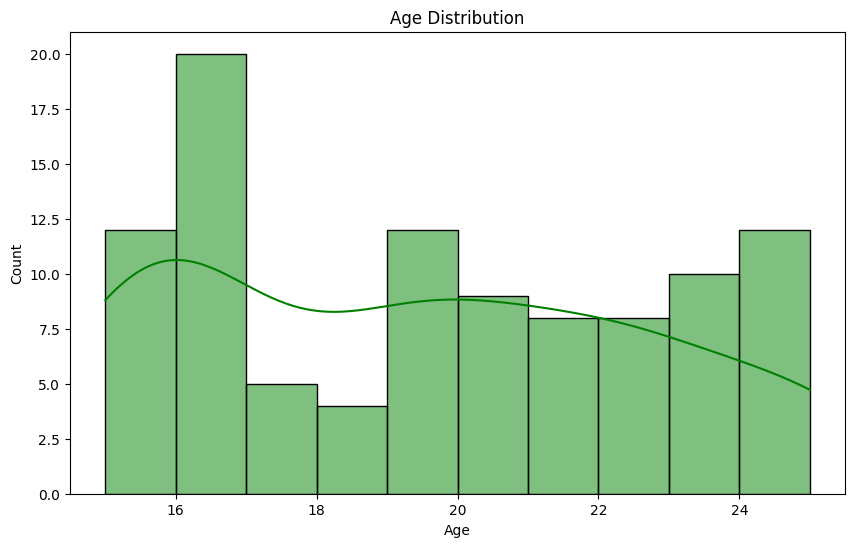

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the Age distribution
plt.figure(figsize=(10,6))
sns.histplot(data['Age'], bins=10, color='green', label='Age Distribution', kde=True)
plt.title("Age Distribution")
plt.show()

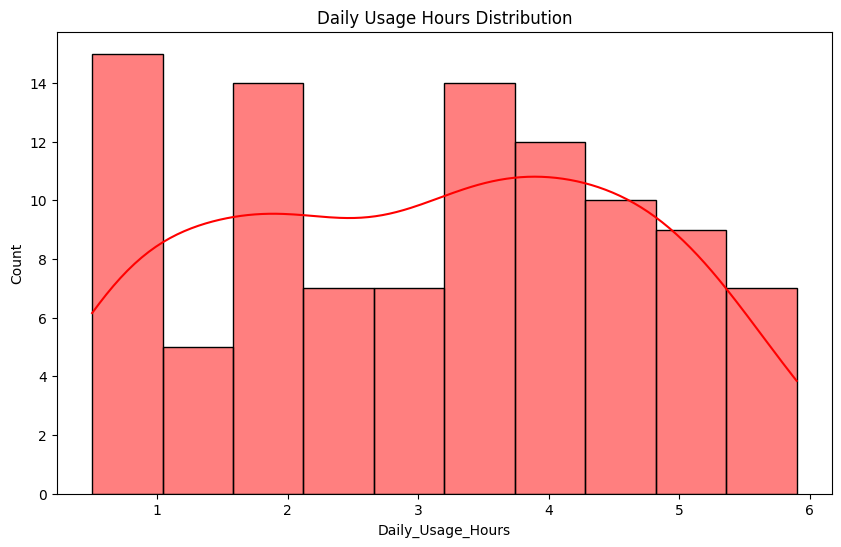

In [10]:
# Visualize the distribution of daily usage hours
plt.figure(figsize=(10,6))
sns.histplot(data['Daily_Usage_Hours'], bins=10, color='red', label='Daily Usage Hours Distribution', kde=True)
plt.title("Daily Usage Hours Distribution")
plt.show()

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_3455/1474834298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="AI_Tool_Used", palette='viridis', ax=axes[0], order=data['AI_Tool_Used'].value_counts().index)
/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_3455/1474834298.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Purpose', palette='magma', ax=axes[1], order=data['Purpose'].value_counts().index)


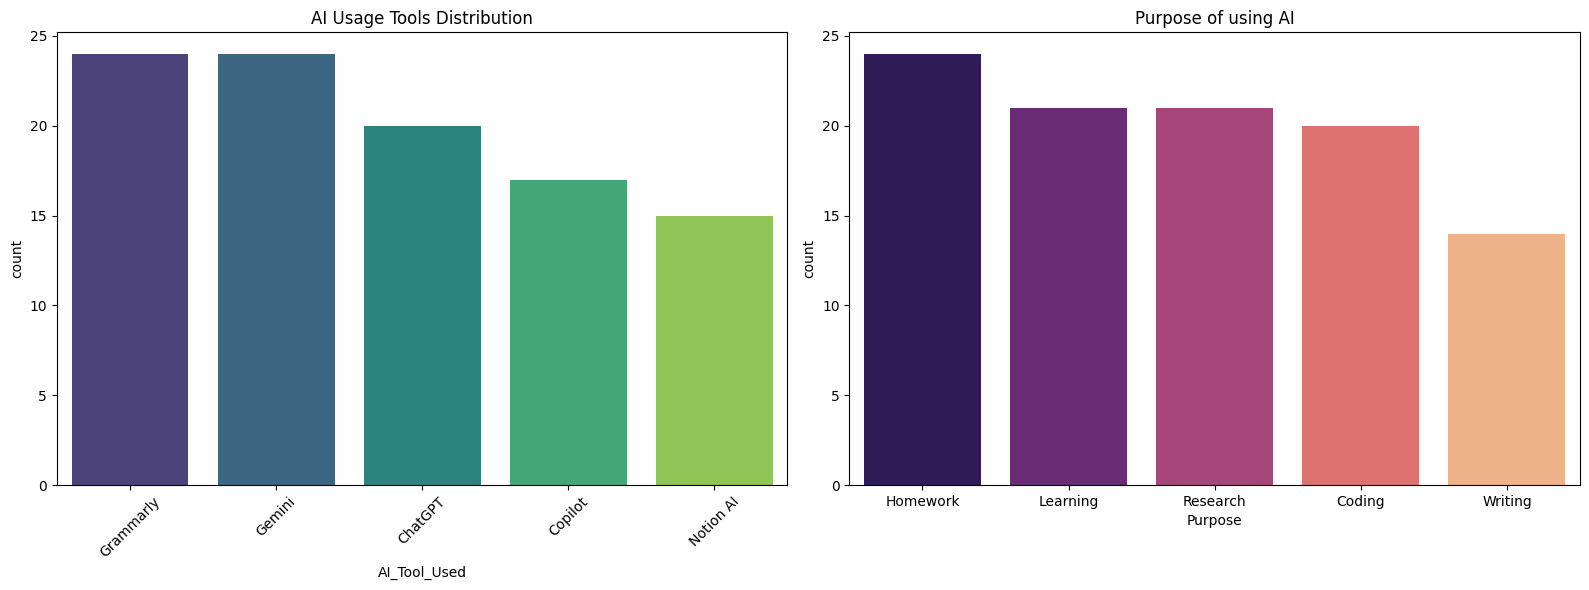

In [11]:
# Which is the most usable AI model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=data, x="AI_Tool_Used", palette='viridis', ax=axes[0], order=data['AI_Tool_Used'].value_counts().index)
axes[0].set_title('AI Usage Tools Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=data, x='Purpose', palette='magma', ax=axes[1], order=data['Purpose'].value_counts().index)
axes[1].set_title('Purpose of using AI')

plt.tight_layout()
plt.show()

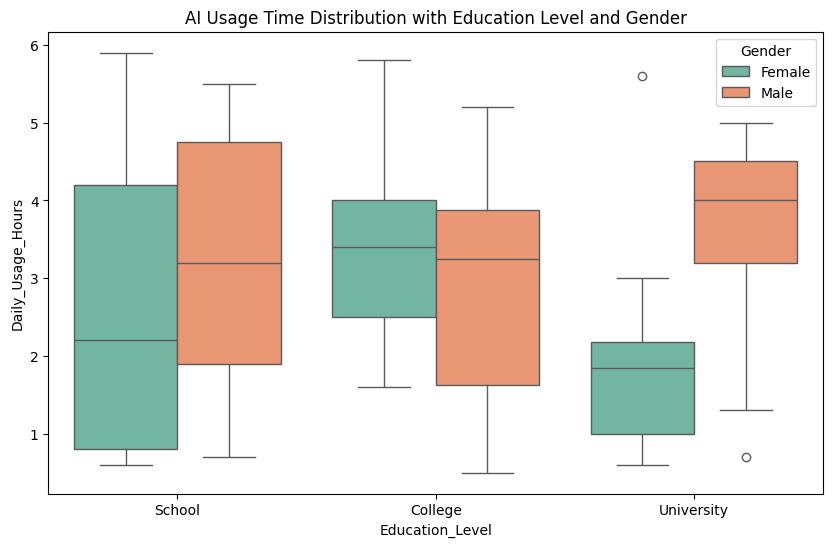

In [12]:
# The Education Level relates with AI Usage Time
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='Education_Level', y='Daily_Usage_Hours', hue='Gender', palette='Set2')
plt.title("AI Usage Time Distribution with Education Level and Gender")
plt.show()

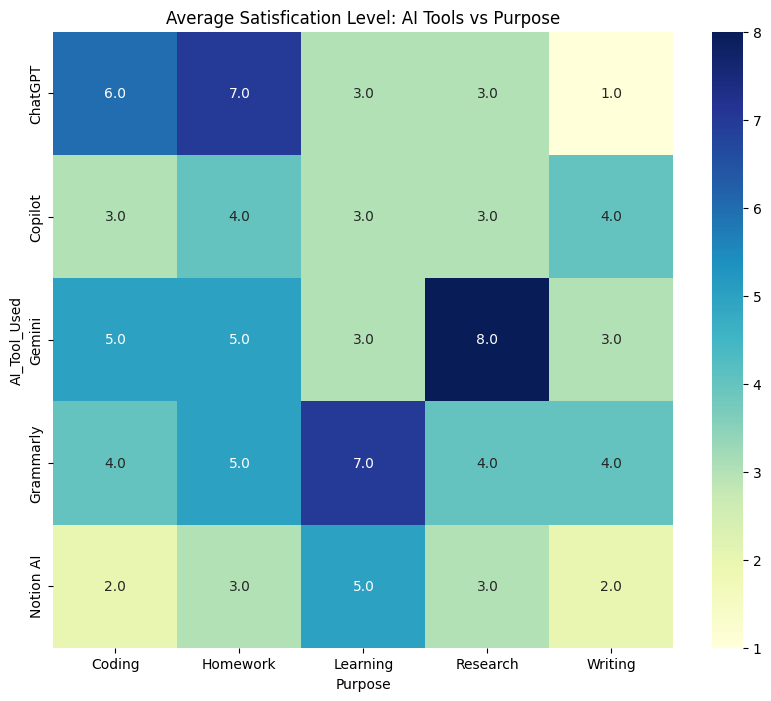

In [13]:
# Which AI Tool would be preferable 
pivot_data = data.pivot_table(index='AI_Tool_Used', columns='Purpose', values='Satisfaction_Level', aggfunc='count')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Average Satisfication Level: AI Tools vs Purpose')
plt.show()

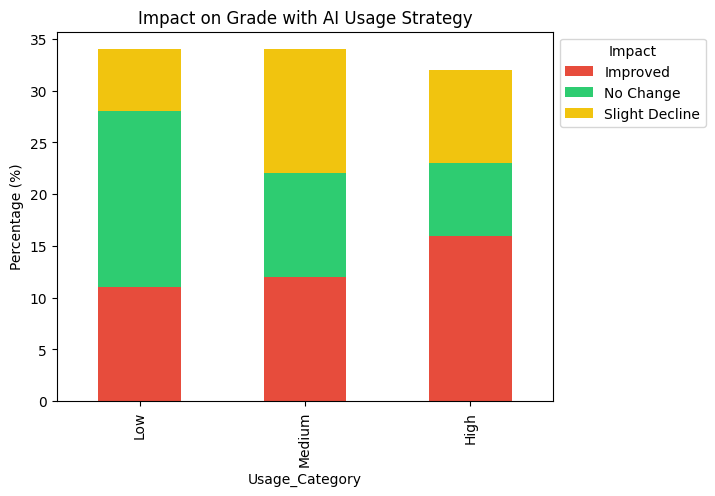

In [14]:
data['Usage_Category'] = pd.cut(data['Daily_Usage_Hours'], bins=[0, 2, 4, 10], labels=['Low', 'Medium', 'High'])
impact_pct = pd.crosstab(data['Usage_Category'], data['Impact_on_Grades'], normalize=True) * 100 

impact_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71', '#f1c40f'])
plt.title('Impact on Grade with AI Usage Strategy')
plt.ylabel('Percentage (%)')
plt.legend(title='Impact', bbox_to_anchor=(1, 1))
plt.show()